# EMG Gesture Classification — Exploratory Analysis

This notebook walks through the full pipeline visually:
1. Raw signal inspection
2. Effect of filtering
3. Gesture segmentation
4. Feature distributions
5. Results summary

Dataset: **NinaPro DB5** — Exercise 1 (12 gestures), 10 subjects, 16 sEMG channels, 200 Hz.

In [13]:
import sys
sys.path.append('..')  # make src/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from src.preprocessing import load_db5_mat, full_filter, extract_windows, compute_normalization_stats, normalize
from src.features import extract_features, FEATURE_NAMES

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# ── Config — adjust path to your data ────────────────────────────────────────
ROOT = Path.cwd()
DATA_DIR   = ROOT / 'EMG_data'
SUBJECT    = 1          # which subject to visualize (1-10)
EXERCISE   = 1          # exercise file (1 = E1)
FS         = 200        # sampling frequency
CHANNEL    = 0          # EMG channel to plot (0-15)

GESTURE_NAMES = [
    'Rest',
    'Thumb up', 'Index+Middle ext.', 'Ring+Little flex.',
    'Thumb opp. little', 'Thumb opp. index', 'Thumb opp. middle',
    'Thumb opp. ring', 'Index flex.', 'Middle flex.',
    'Ring flex.', 'Little flex.', 'Fist'
]
print('Setup complete.')

Setup complete.


## 1. Load a single subject

In [15]:
mat_path = DATA_DIR / f'S{SUBJECT}_E{EXERCISE}_A1.mat'
data = load_db5_mat(str(mat_path))

emg       = data['emg']        # (T, 16)
stimulus  = data['stimulus']   # (T,)
repetition = data['repetition'] # (T,)

print(f'EMG shape     : {emg.shape}')
print(f'Duration      : {emg.shape[0]/FS:.1f} s')
print(f'Gestures      : {np.unique(stimulus)}')
print(f'Repetitions   : {np.unique(repetition)}')
print(f'EMG range     : [{emg.min():.4f}, {emg.max():.4f}]')

EMG shape     : (130267, 16)
Duration      : 651.3 s
Gestures      : [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Repetitions   : [0 1 2 3 4 5 6]
EMG range     : [-128.0000, 127.0000]


## 2. Raw signal overview — all 16 channels

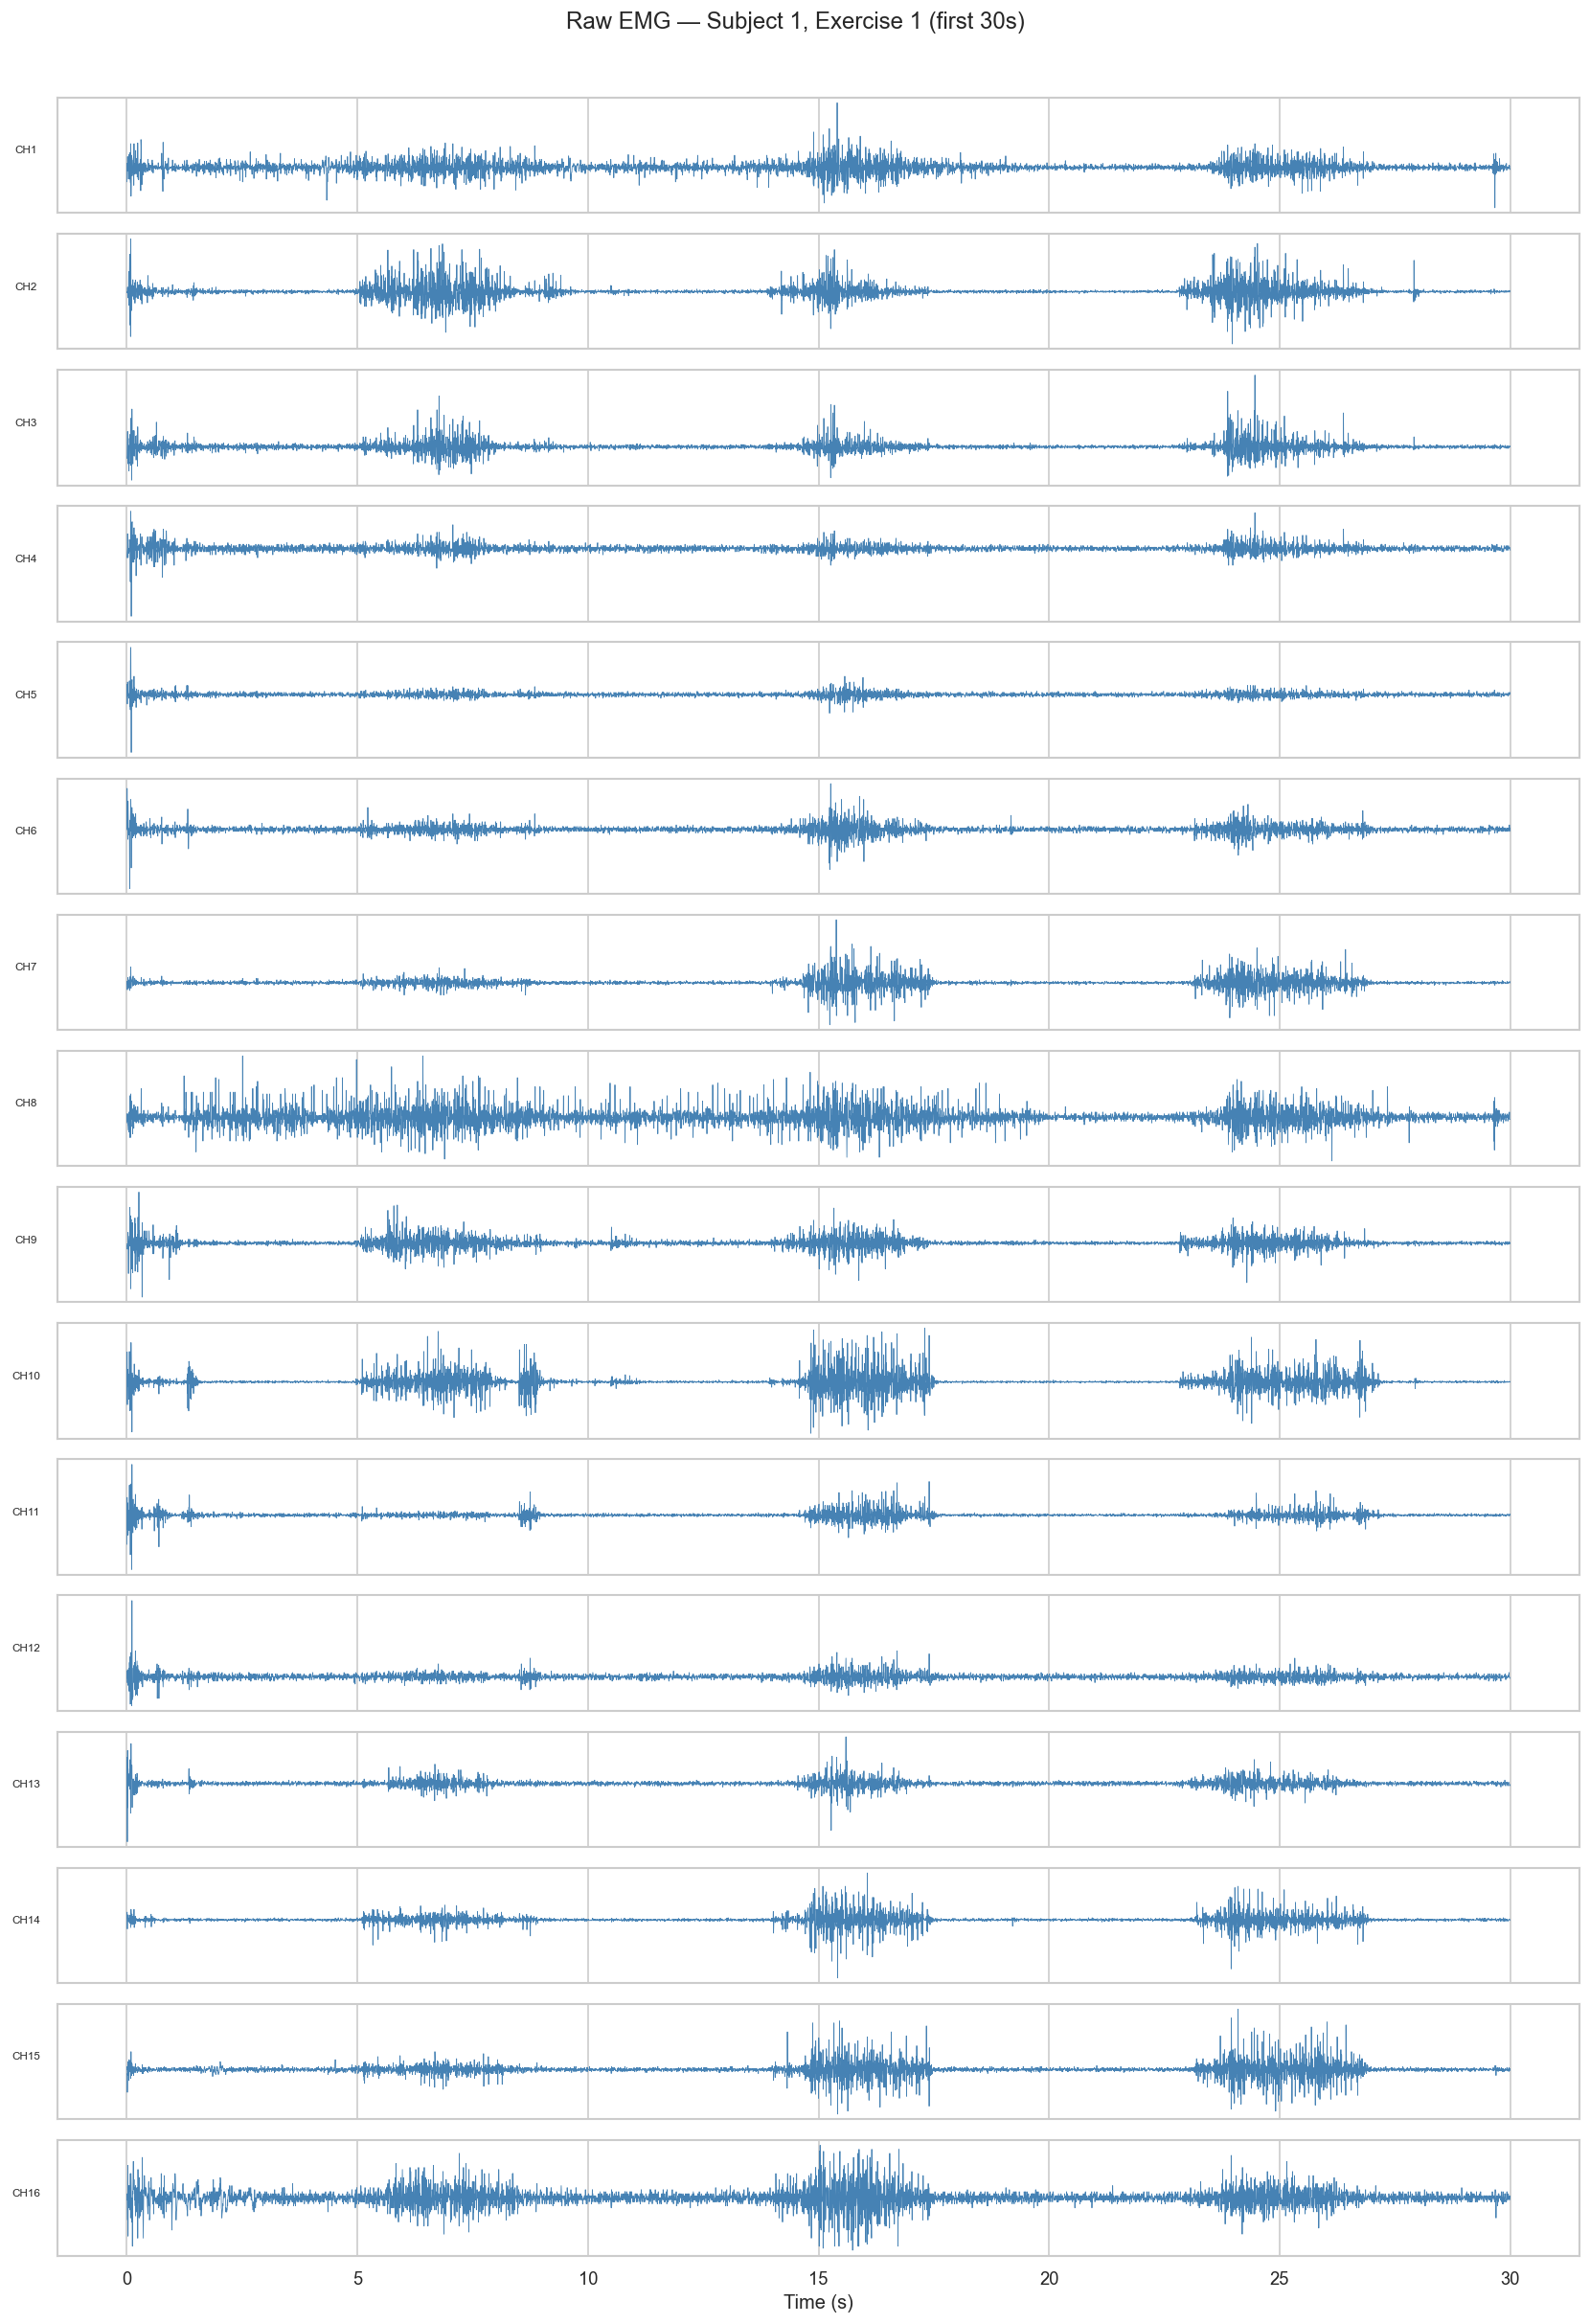

In [16]:
t = np.arange(emg.shape[0]) / FS
# Show first 30 seconds for readability
mask = t <= 30

fig, axes = plt.subplots(16, 1, figsize=(14, 20), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(t[mask], emg[mask, ch], lw=0.5, color='steelblue')
    ax.set_ylabel(f'CH{ch+1}', fontsize=7, rotation=0, labelpad=20)
    ax.set_yticks([])

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw EMG — Subject {SUBJECT}, Exercise {EXERCISE} (first 30s)', y=1.01)
plt.tight_layout()
plt.show()

## 3. Effect of filtering — raw vs filtered

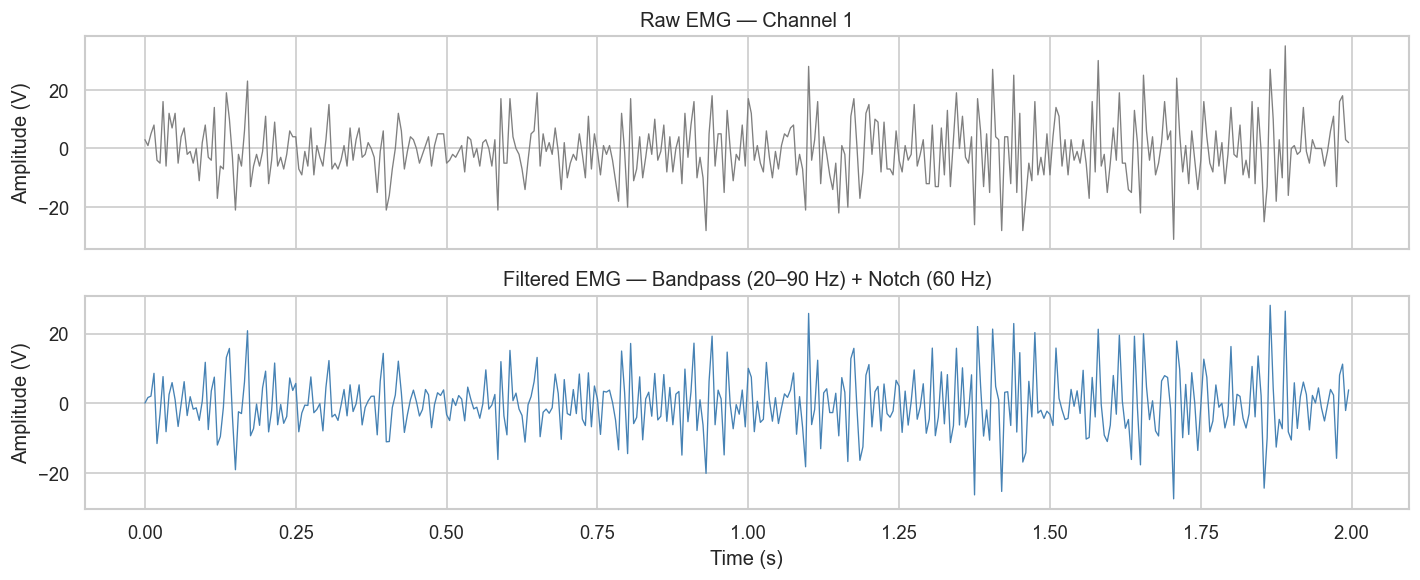

In [17]:
emg_filtered = full_filter(emg, notch_freq=60.0)

# Pick a 2-second window during an active gesture
# Find first non-rest sample
start = np.where(stimulus > 0)[0][0]
end   = start + 2 * FS
t_seg = np.arange(end - start) / FS

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t_seg, emg[start:end, CHANNEL], lw=0.8, color='gray')
axes[0].set_title(f'Raw EMG — Channel {CHANNEL+1}')
axes[0].set_ylabel('Amplitude (V)')

axes[1].plot(t_seg, emg_filtered[start:end, CHANNEL], lw=0.8, color='steelblue')
axes[1].set_title(f'Filtered EMG — Bandpass (20–90 Hz) + Notch (60 Hz)')
axes[1].set_ylabel('Amplitude (V)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 4. Power spectral density — raw vs filtered

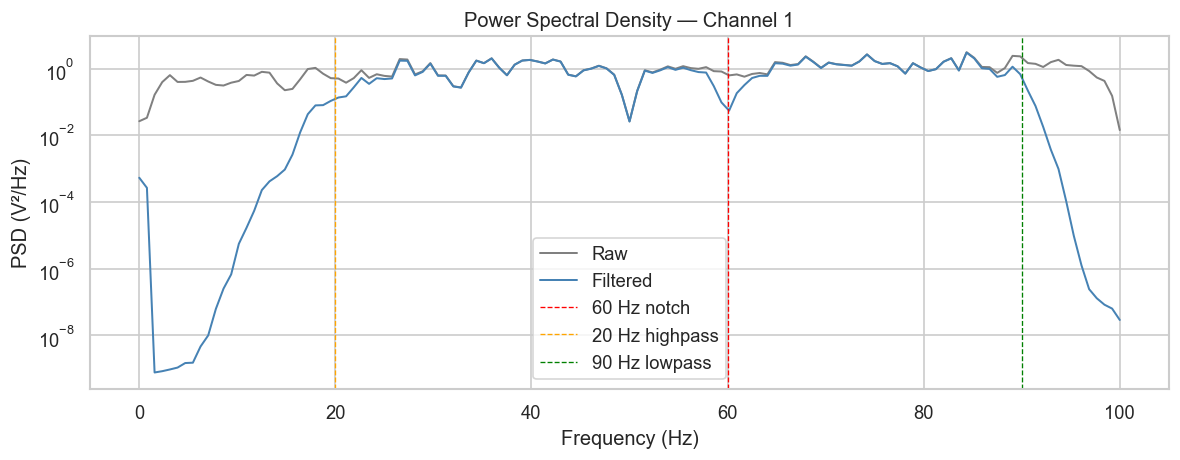

In [18]:
from scipy import signal as sp_signal

seg_raw  = emg[start:start + 5*FS, CHANNEL]
seg_filt = emg_filtered[start:start + 5*FS, CHANNEL]

f_raw,  psd_raw  = sp_signal.welch(seg_raw,  fs=FS, nperseg=256)
f_filt, psd_filt = sp_signal.welch(seg_filt, fs=FS, nperseg=256)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(f_raw,  psd_raw,  label='Raw',      color='gray',      lw=1.2)
ax.semilogy(f_filt, psd_filt, label='Filtered', color='steelblue', lw=1.2)
ax.axvline(60, color='red',    ls='--', lw=0.8, label='60 Hz notch')
ax.axvline(20, color='orange', ls='--', lw=0.8, label='20 Hz highpass')
ax.axvline(90, color='green',  ls='--', lw=0.8, label='90 Hz lowpass')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title(f'Power Spectral Density — Channel {CHANNEL+1}')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Gesture segmentation — stimulus overlay

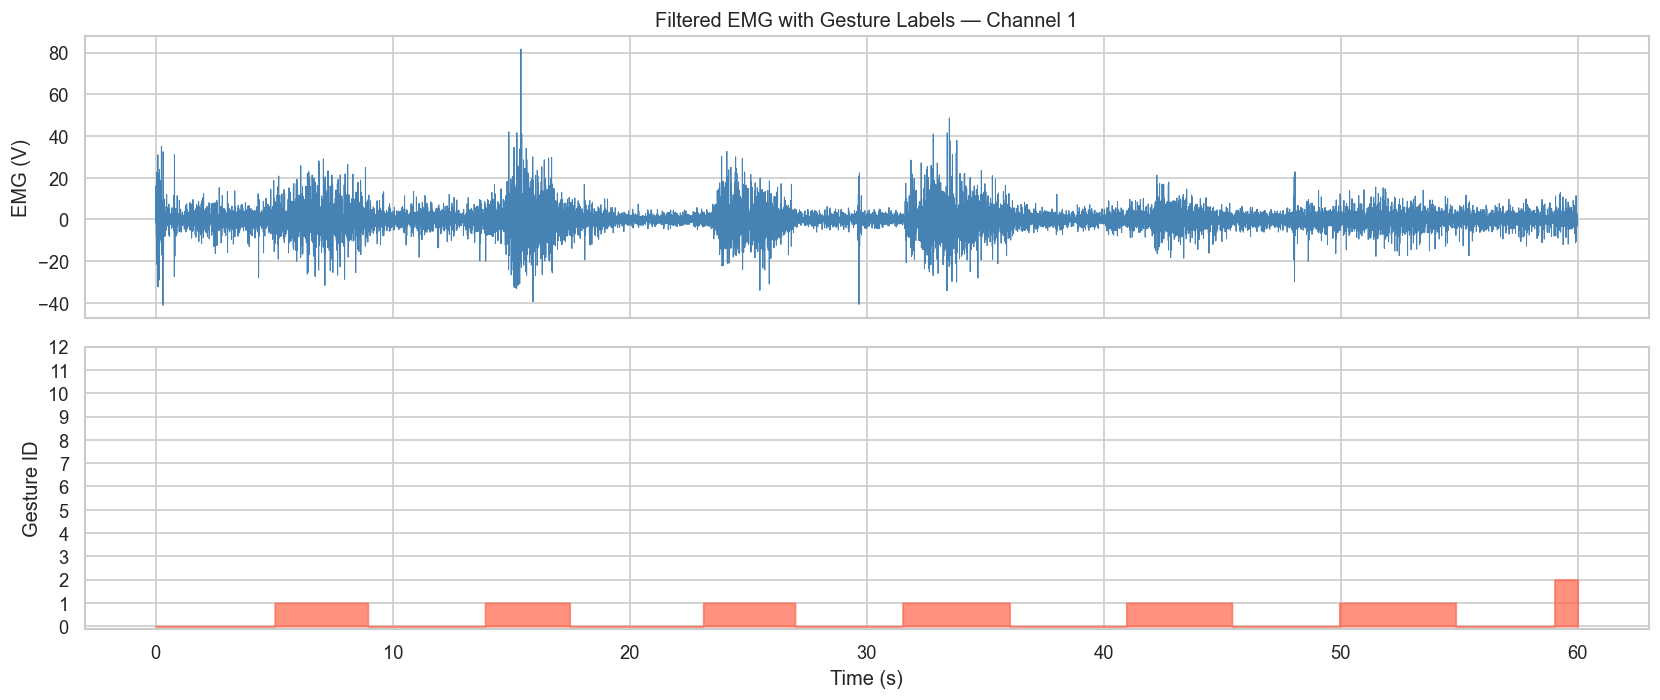

In [19]:
# Show first 60 seconds with gesture label overlay
mask60 = t <= 60
t60    = t[mask60]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(t60, emg_filtered[mask60, CHANNEL], lw=0.6, color='steelblue')
ax1.set_ylabel('EMG (V)')
ax1.set_title(f'Filtered EMG with Gesture Labels — Channel {CHANNEL+1}')

ax2.fill_between(t60, stimulus[mask60], step='mid', alpha=0.7, color='tomato')
ax2.set_ylabel('Gesture ID')
ax2.set_xlabel('Time (s)')
ax2.set_yticks(range(0, 13))

plt.tight_layout()
plt.show()

## 6. Average EMG envelope per gesture

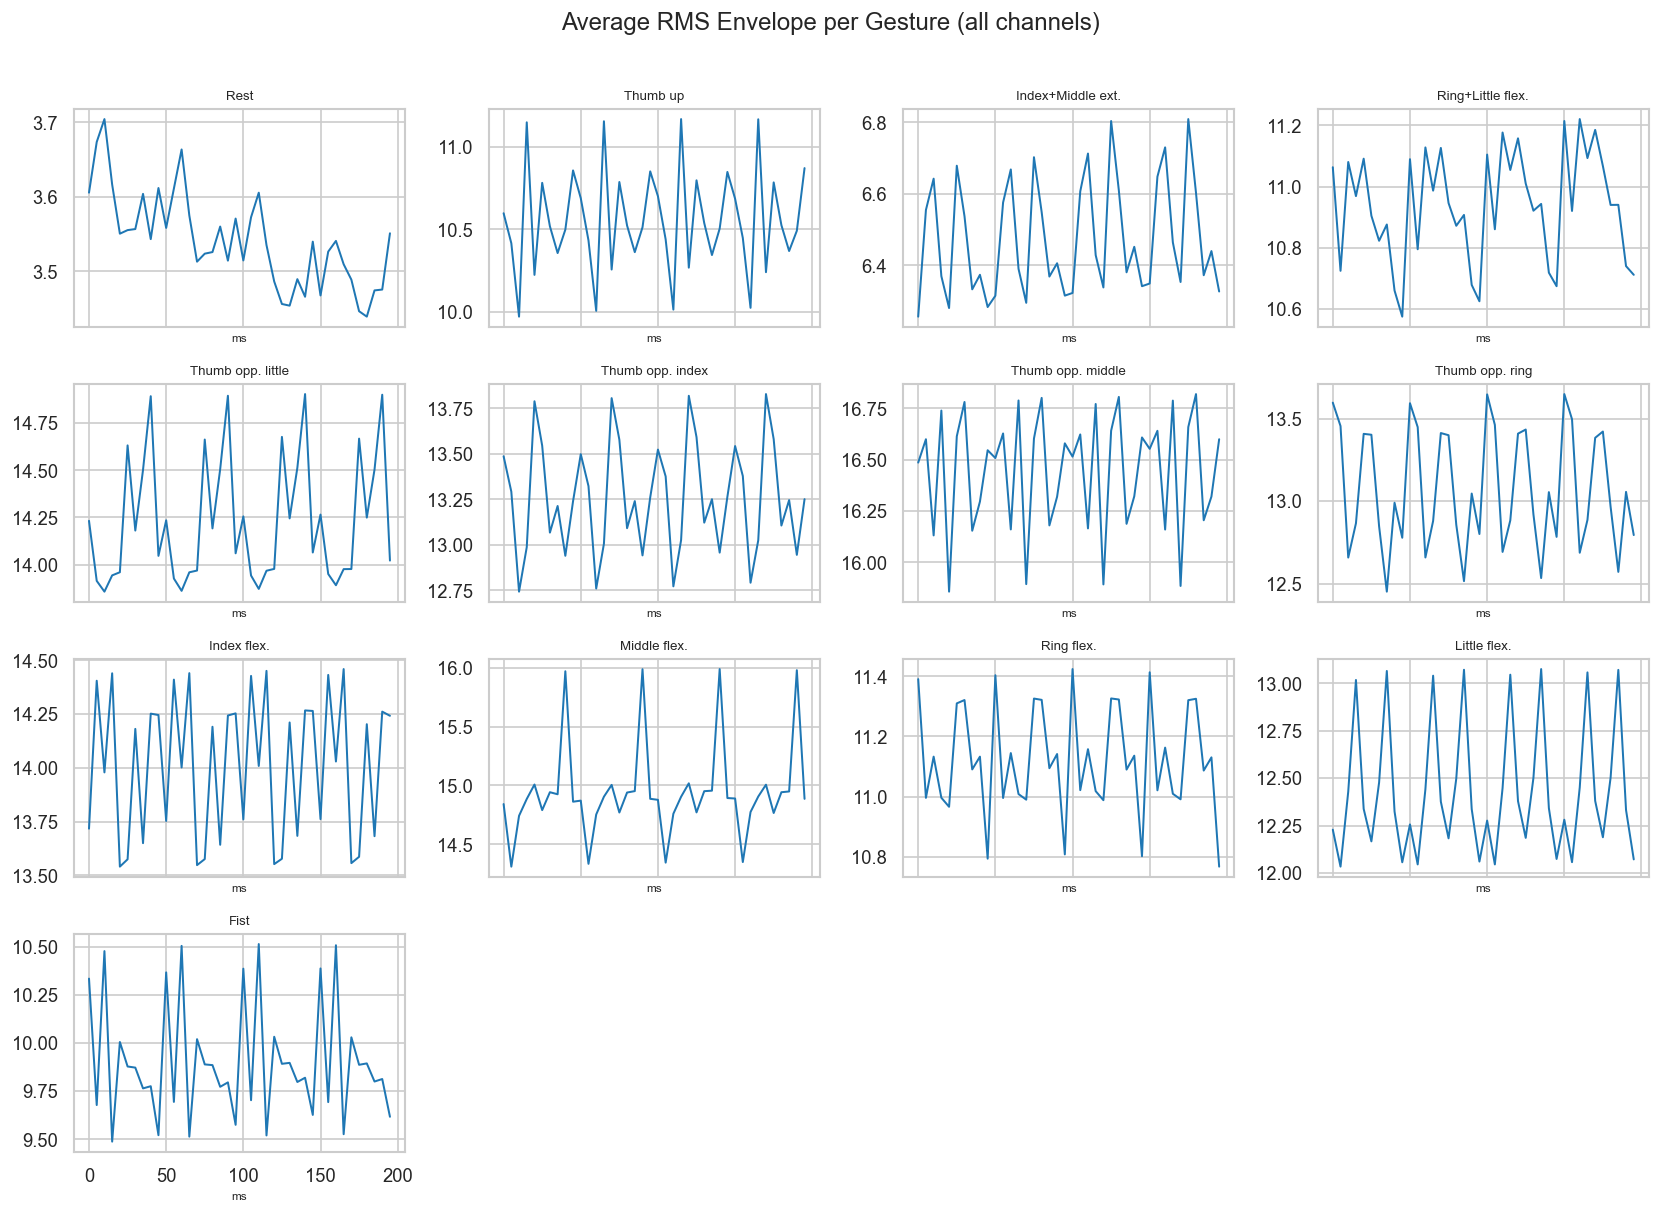

In [20]:
# Segment and extract windows for visualization
splits = extract_windows(emg_filtered, stimulus, repetition,
                         window_ms=200, step_ms=50,
                         exclude_rest=False)
X_train, y_train = splits['train']

gestures = np.unique(y_train)
n_gest   = len(gestures)
cols     = 4
rows     = int(np.ceil(n_gest / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 2.5), sharex=True)
axes = axes.flatten()

for i, g in enumerate(gestures):
    idx     = np.where(y_train == g)[0]
    windows = X_train[idx]              # (N, win, 16)
    # RMS envelope averaged across windows and channels
    envelope = np.sqrt(np.mean(windows ** 2, axis=(0, 2)))  # (win,)
    t_win    = np.arange(len(envelope)) / FS * 1000

    axes[i].plot(t_win, envelope, lw=1.2)
    name = GESTURE_NAMES[g] if g < len(GESTURE_NAMES) else f'Gesture {g}'
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel('ms', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Average RMS Envelope per Gesture (all channels)', y=1.01)
plt.tight_layout()
plt.show()

## 7. Feature distributions — MAV per gesture

C:\Users\maina\anaconda3\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 256 is greater than input length  = 40, using nperseg = 40
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


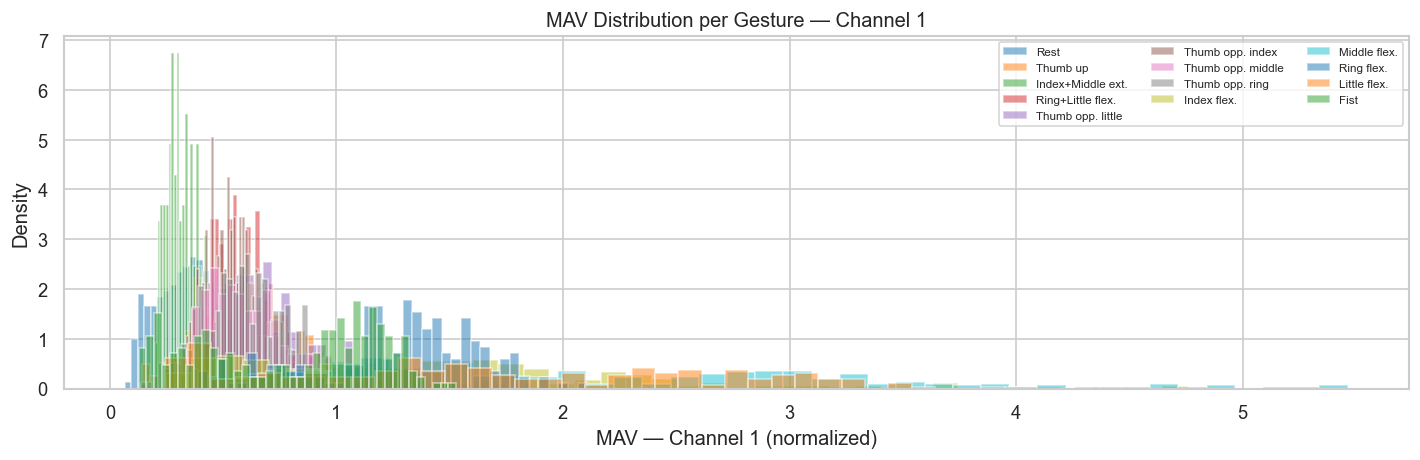

In [21]:
from sklearn.preprocessing import LabelEncoder

mean, std = compute_normalization_stats(X_train)
X_norm    = normalize(X_train, mean, std)
F_train   = extract_features(X_norm)   # (N, 144)

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

# MAV of channel 0 = feature index 0
mav_ch0 = F_train[:, 0]

fig, ax = plt.subplots(figsize=(12, 4))
for g_enc, g_orig in enumerate(le.classes_):
    vals = mav_ch0[y_enc == g_enc]
    name = GESTURE_NAMES[g_orig] if g_orig < len(GESTURE_NAMES) else f'G{g_orig}'
    ax.hist(vals, bins=40, alpha=0.5, label=name, density=True)

ax.set_xlabel('MAV — Channel 1 (normalized)')
ax.set_ylabel('Density')
ax.set_title('MAV Distribution per Gesture — Channel 1')
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

## 8. Results summary

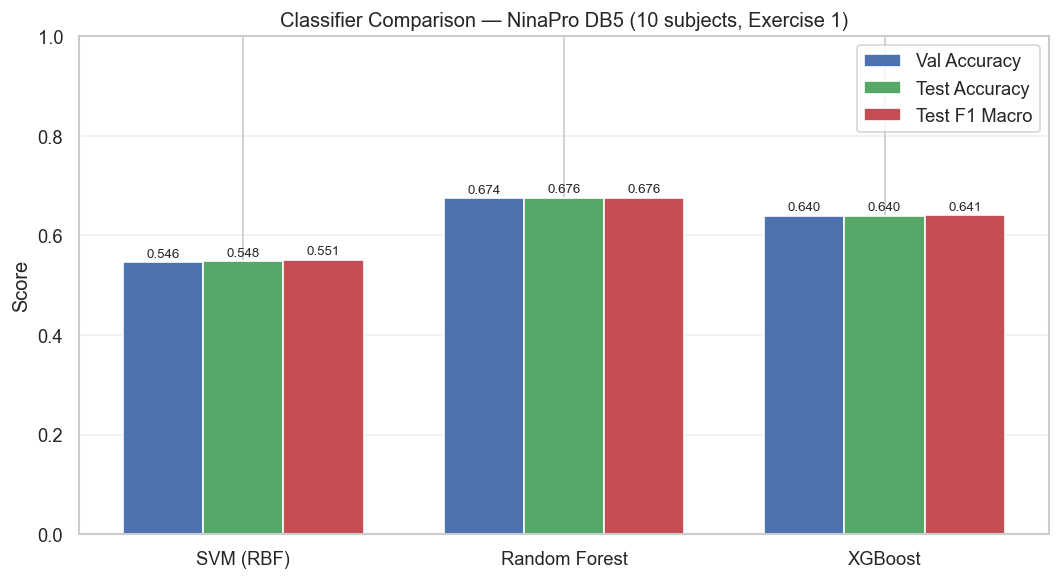


Detailed metrics:
  SVM (RBF)            | val: 0.5459 | test: 0.5481 | F1: 0.5513
  Random Forest        | val: 0.6744 | test: 0.6758 | F1: 0.6760
  XGBoost              | val: 0.6397 | test: 0.6399 | F1: 0.6407


In [25]:
import json

metrics_path = ROOT / 'results/metrics.json'

if metrics_path.exists():
    with open(metrics_path) as f:
        metrics = json.load(f)

    models   = list(metrics.keys())
    val_acc  = [metrics[m]['val_accuracy']  for m in models]
    test_acc = [metrics[m]['test_accuracy'] for m in models]
    f1       = [metrics[m]['test_f1_macro'] for m in models]

    x     = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width, val_acc,  width, label='Val Accuracy',  color='#4C72B0')
    ax.bar(x,         test_acc, width, label='Test Accuracy', color='#55A868')
    ax.bar(x + width, f1,       width, label='Test F1 Macro', color='#C44E52')

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('Score')
    ax.set_title('Classifier Comparison — NinaPro DB5 (10 subjects, Exercise 1)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for i, (v, t, f) in enumerate(zip(val_acc, test_acc, f1)):
        ax.text(i - width, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
        ax.text(i,         t + 0.01, f'{t:.3f}', ha='center', fontsize=8)
        ax.text(i + width, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print('\nDetailed metrics:')
    for m, v in metrics.items():
        print(f'  {m:20s} | val: {v["val_accuracy"]:.4f} | test: {v["test_accuracy"]:.4f} | F1: {v["test_f1_macro"]:.4f}')
else:
    print('Run main.py first to generate results/metrics.json')